In [65]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [66]:
#loading dataframe

In [67]:
df = pd.read_csv('vendas_desafio.csv')

In [68]:
df.head(5)

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_venda        10000 non-null  int64  
 1   data_venda      10000 non-null  object 
 2   cliente         10000 non-null  object 
 3   produto         10000 non-null  object 
 4   categoria       10000 non-null  object 
 5   quantidade      10000 non-null  int64  
 6   preco_unitario  10000 non-null  float64
 7   vendedor        10000 non-null  object 
 8   cidade          10000 non-null  object 
 9   estado          10000 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 781.4+ KB


Part 1 - Analysis with SQL

In [70]:
#Loading dataframe with SQL

In [71]:
import sqlite3

# building database in the memory
conn = sqlite3.connect(":memory:")

# jogar o dataframe como tabela
df.to_sql("tabela", conn, index=False, if_exists="replace")

# rodar SQL
query = """
SELECT *
FROM tabela
LIMIT 10;
"""
resultado = pd.read_sql(query, conn)
print(resultado)

   id_venda  data_venda     cliente    produto    categoria  quantidade  \
0         1  2024-09-27      Pietra      Mouse  Eletrônicos           3   
1         2  2024-01-21    Vinicius    Monitor  Eletrônicos           3   
2         3  2024-08-02        Yago      Mouse  Eletrônicos           3   
3         4  2024-04-09        Lara   Notebook  Eletrônicos           3   
4         5  2024-05-29        Levi       Fone  Eletrônicos           4   
5         6  2024-10-20  Ravi Lucca    Monitor  Eletrônicos           1   
6         7  2024-10-03      Thales  Livro SQL       Livros           2   
7         8  2024-01-22        José    Teclado  Eletrônicos           1   
8         9  2024-02-18      Isabel    Teclado  Eletrônicos           1   
9        10  2024-06-18        Luan      Mouse  Eletrônicos           3   

   preco_unitario vendedor          cidade estado  
0           84.74      Ana  Belo Horizonte     RJ  
1          950.34    Bruno       São Paulo     RS  
2           79.13 

In [72]:
# Total revenue per product

In [73]:
query2 = """
SELECT 
produto,
SUM(preco_unitario*quantidade) as revenue,
RANK() OVER(ORDER BY SUM(preco_unitario*quantidade) DESC) as Ranking
FROM
tabela
GROUP BY produto
"""

In [74]:
answer_1 = pd.read_sql(query2,conn)  

In [75]:
answer_1

,produto,revenue,Ranking
0,Notebook,8290852.39,1
1,Mesa,3092939.21,2
2,Monitor,2364641.86,3
3,Cadeira,1629832.30,4
4,Fone,495633.09,5
5,Mochila,460376.91,6
6,Teclado,384771.59,7
7,Livro Python,296630.22,8
8,Livro SQL,247460.70,9
9,Mouse,205764.16,10


In [76]:
# total_revenue per category

In [77]:
query3 = """
SELECT 
categoria,
SUM(preco_unitario*quantidade) as revenue,
RANK() OVER(ORDER BY SUM(preco_unitario*quantidade) DESC) AS ranking
FROM tabela
GROUP BY categoria
"""

In [78]:
answer_2 = pd.read_sql(query3,conn)

In [79]:
answer_2 

,categoria,revenue,ranking
0,Eletrônicos,11741663.09,1
1,Móveis,4722771.51,2
2,Livros,544090.92,3
3,Acessórios,460376.91,4


In [80]:
# medium ticket per client

In [81]:
query4 = """
SELECT 
x.cliente,
x.revenue,
x.quantity_order,
x.revenue/x.quantity_order as medium_ticket,
RANK() OVER(ORDER BY x.revenue/x.quantity_order DESC) as Ranking
FROM (
SELECT 
cliente,
SUM(preco_unitario*quantidade) as revenue,
COUNT(DISTINCT id_venda) as quantity_order
FROM
tabela
GROUP BY cliente) as x
"""

In [82]:
answer_3 = pd.read_sql(query4,conn)

In [83]:
answer_3

,cliente,revenue,quantity_order,medium_ticket,Ranking
0,Mathias,122641.69,41,2991.260732,1
1,Isabelly,80187.94,27,2969.923704,2
2,Thiago,107474.24,38,2828.269474,3
3,Danilo,78792.49,28,2814.017500,4
4,Nicole,85804.88,31,2767.899355,5
...,...,...,...,...,...
277,Maria Liz,30258.40,40,756.460000,278
278,Liam,28479.58,39,730.245641,279
279,Gabriel,26758.78,39,686.122564,280
280,Mariane,22230.06,34,653.825294,281


In [84]:
# total revenue per seller

In [85]:
query5 = """
SELECT 
x.vendedor,
x.revenue,
RANK() OVER(ORDER BY x.revenue DESC) AS ranking
FROM 
(SELECT 
vendedor,
SUM(preco_unitario*quantidade) as revenue
FROM
tabela
GROUP BY vendedor) as x
"""

In [86]:
answer_4 = pd.read_sql(query5,conn)

In [87]:
answer_4

,vendedor,revenue,ranking
0,Ana,3544588.45,1
1,Bruno,3501930.96,2
2,Eduardo,3477302.18,3
3,Carlos,3476724.22,4
4,Daniela,3468356.62,5


In [88]:
# total revenue per month

In [89]:
query6 = """
SELECT 
CASE
    WHEN xx.month == '01' THEN 'January'
    WHEN xx.month == '02' THEN 'February'
    WHEN xx.month == '03' THEN 'March'
    WHEN xx.month == '04' THEN 'April'
    WHEN xx.month == '05' THEN 'May'
    WHEN xx.month == '06' THEN 'June'
    WHEN xx.month == '07' THEN 'July'
    WHEN xx.month == '08' THEN 'August'
    WHEN xx.month == '09' THEN 'September'
    WHEN xx.month == '10' THEN 'Octuber'
    WHEN xx.month == '11' THEN 'November'
    WHEN xx.month == '12' THEN 'December'
END AS Month,
xx.Revenue
FROM (SELECT 
x.month,
SUM(x.preco_unitario*x.quantidade) as Revenue
FROM (SELECT 
preco_unitario,
quantidade,
strftime('%m',data_venda) as month
FROM
tabela) as x
GROUP BY x.month) AS xx
"""

In [90]:
answer_5 = pd.read_sql(query6,conn)

In [91]:
answer_5

,Month,Revenue
0,January,1332505.24
1,February,1414699.44
2,March,1561420.22
3,April,1571459.42
4,May,1537043.09
5,June,1346568.09
6,July,1528937.90
7,August,1531974.02
8,September,1560269.23
9,Octuber,1423821.79


In [92]:
# Five products most sold

In [93]:
query7 = """
SELECT 
produto as product,
SUM(quantidade) as quantity,
RANK() OVER(ORDER BY SUM(quantidade) DESC) AS Ranking
FROM
tabela
GROUP BY produto
LIMIT 5
"""

In [94]:
answer_6 = pd.read_sql(query7,conn)

In [95]:
answer_6

,product,quantity,Ranking
0,Monitor,2613,1
1,Mouse,2581,2
2,Mesa,2581,2
3,Teclado,2566,4
4,Mochila,2557,5


In [96]:
# The city with more revenue

In [97]:
query8 = """
SELECT 
cidade as city,
SUM(preco_unitario*quantidade) as Revenue,
RANK() OVER(ORDER BY SUM(preco_unitario*quantidade) DESC) AS Ranking
FROM
tabela
GROUP BY cidade
LIMIT 1
"""

In [98]:
answer_7 = pd.read_sql(query8,conn)

In [99]:
answer_7

,city,Revenue,Ranking
0,Curitiba,3636297.53,1


In [100]:
# Who was the client that most bought in value

In [101]:
query9 = """
SELECT 
cliente as client,
SUM(preco_unitario*quantidade) as Revenue,
RANK() OVER(ORDER BY SUM(preco_unitario*quantidade) DESC) AS Ranking
FROM
tabela
GROUP BY cliente
LIMIT 1
"""

In [102]:
answer_8 = pd.read_sql(query9,conn)

In [103]:
answer_8

,client,Revenue,Ranking
0,Mathias,122641.69,1


In [104]:
# Table with product, category, total quantity, total revenue

In [105]:
query10 = """

CREATE TABLE resumo_vendas AS
SELECT 
produto as product,
categoria as category,
SUM(quantidade) as quantity,
SUM(preco_unitario*quantidade) as revenue
FROM tabela
GROUP BY produto,categoria;

"""

In [106]:
cursor = conn.cursor()
cursor.executescript(query10)
conn.commit()

In [107]:
resume_sales = pd.read_sql("SELECT * from resumo_vendas",conn)

In [108]:
resume_sales

,product,category,quantity,revenue
0,Cadeira,Móveis,2319,1629832.30
1,Fone,Eletrônicos,2469,495633.09
2,Livro Python,Livros,2470,296630.22
3,Livro SQL,Livros,2474,247460.70
4,Mesa,Móveis,2581,3092939.21
5,Mochila,Acessórios,2557,460376.91
6,Monitor,Eletrônicos,2613,2364641.86
7,Mouse,Eletrônicos,2581,205764.16
8,Notebook,Eletrônicos,2364,8290852.39
9,Teclado,Eletrônicos,2566,384771.59


In [109]:
# export to csv table resume sales

In [110]:
resume_sales.to_csv('resumo_sales.csv')

Part 2 - Analysis with Python

In [111]:
# created column 'faturamento' 

In [112]:
df.head(5)

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS


In [113]:
df['faturamento'] = df['quantidade']*df['preco_unitario']

In [114]:
df.head(10)

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado,faturamento
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ,254.22
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS,2851.02
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP,237.39
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ,10414.41
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS,833.28
5,6,2024-10-20,Ravi Lucca,Monitor,Eletrônicos,1,984.58,Eduardo,Curitiba,RJ,984.58
6,7,2024-10-03,Thales,Livro SQL,Livros,2,93.64,Eduardo,Belo Horizonte,SP,187.28
7,8,2024-01-22,José,Teclado,Eletrônicos,1,144.13,Daniela,Belo Horizonte,MG,144.13
8,9,2024-02-18,Isabel,Teclado,Eletrônicos,1,147.96,Bruno,Belo Horizonte,SP,147.96
9,10,2024-06-18,Luan,Mouse,Eletrônicos,3,81.79,Daniela,São Paulo,MG,245.37


In [115]:
# Preparation of dataframe

In [116]:
# check types of columns

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_venda        10000 non-null  int64  
 1   data_venda      10000 non-null  object 
 2   cliente         10000 non-null  object 
 3   produto         10000 non-null  object 
 4   categoria       10000 non-null  object 
 5   quantidade      10000 non-null  int64  
 6   preco_unitario  10000 non-null  float64
 7   vendedor        10000 non-null  object 
 8   cidade          10000 non-null  object 
 9   estado          10000 non-null  object 
 10  faturamento     10000 non-null  float64
dtypes: float64(2), int64(2), object(7)
memory usage: 859.5+ KB


In [118]:
df.describe()

,id_venda,quantidade,preco_unitario,faturamento
count,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,2.499400,703.195273,1746.890243
std,2886.89568,1.117642,992.868916,2792.186754
min,1.00000,1.000000,72.010000,72.050000
25%,2500.75000,2.000000,119.615000,261.405000
50%,5000.50000,2.000000,188.325000,556.275000
75%,7500.25000,3.000000,908.267500,2241.562500
max,10000.00000,4.000000,3848.760000,15385.480000


In [119]:
# check null values

In [120]:
df.isnull().sum()

id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
quantidade        0
preco_unitario    0
vendedor          0
cidade            0
estado            0
faturamento       0
dtype: int64

In [121]:
#check duplicate values in the columns

In [122]:
for i in df.columns:
    print(i)
    print(df.duplicated(subset=i,keep=False))

id_venda
0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool
data_venda
0       True
1       True
2       True
3       True
4       True
        ... 
9995    True
9996    True
9997    True
9998    True
9999    True
Length: 10000, dtype: bool
cliente
0       True
1       True
2       True
3       True
4       True
        ... 
9995    True
9996    True
9997    True
9998    True
9999    True
Length: 10000, dtype: bool
produto
0       True
1       True
2       True
3       True
4       True
        ... 
9995    True
9996    True
9997    True
9998    True
9999    True
Length: 10000, dtype: bool
categoria
0       True
1       True
2       True
3       True
4       True
        ... 
9995    True
9996    True
9997    True
9998    True
9999    True
Length: 10000, dtype: bool
quantidade
0       True
1       True
2       True
3       True
4       True
        ... 
9995

In [123]:
#Exploratory Analysis

In [124]:
cols = [
    'quantidade',
    'preco_unitario',
    'faturamento'
]

In [125]:
#Histogram

In [126]:
#normal scale

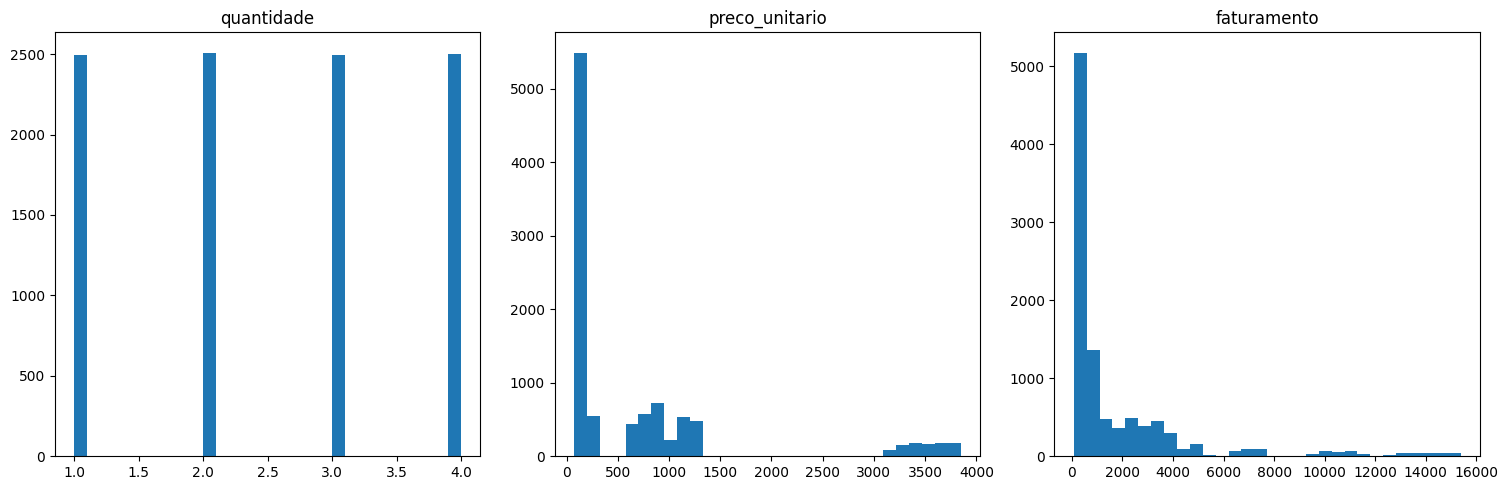

In [127]:
plt.figure(figsize=(15,5))
for i, col in enumerate(cols):
    plt.subplot(1,3,i+1)
    data = df[col]
    data = data[data>0]
    plt.hist(data,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

In [128]:
#log scale

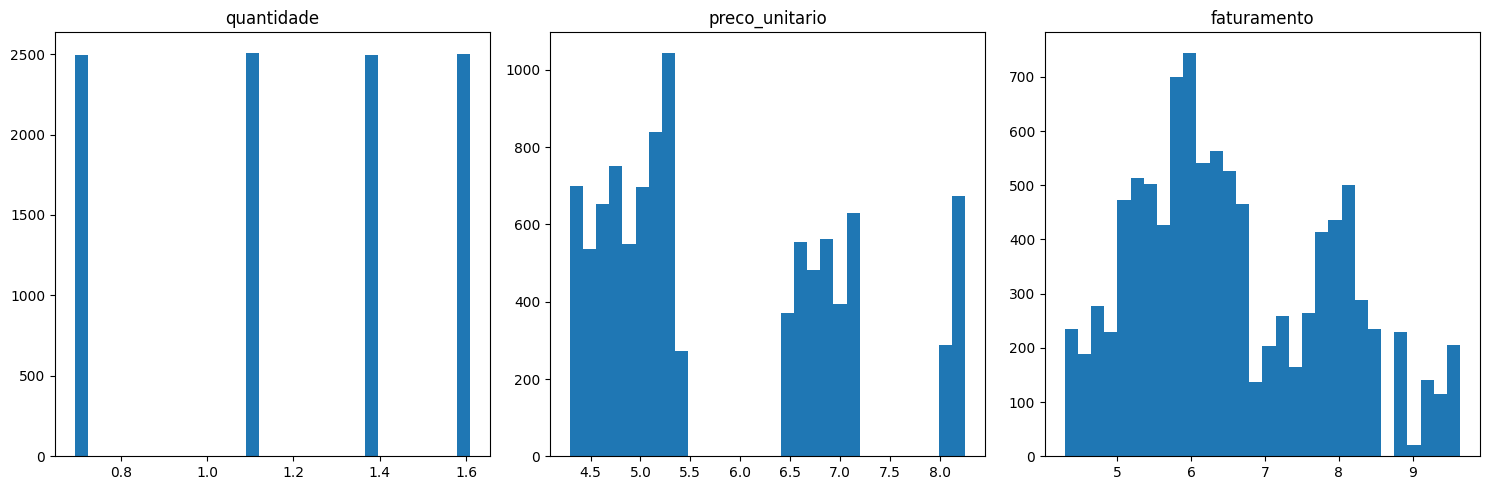

In [129]:
plt.figure(figsize=(15,5))
for i, col in enumerate(cols):
    plt.subplot(1,3,i+1)
    data = df[col]
    data = data[data>0]
    plt.hist(np.log1p(data),bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

In [130]:
#Boxplot numeric variables

In [131]:
#normal scale

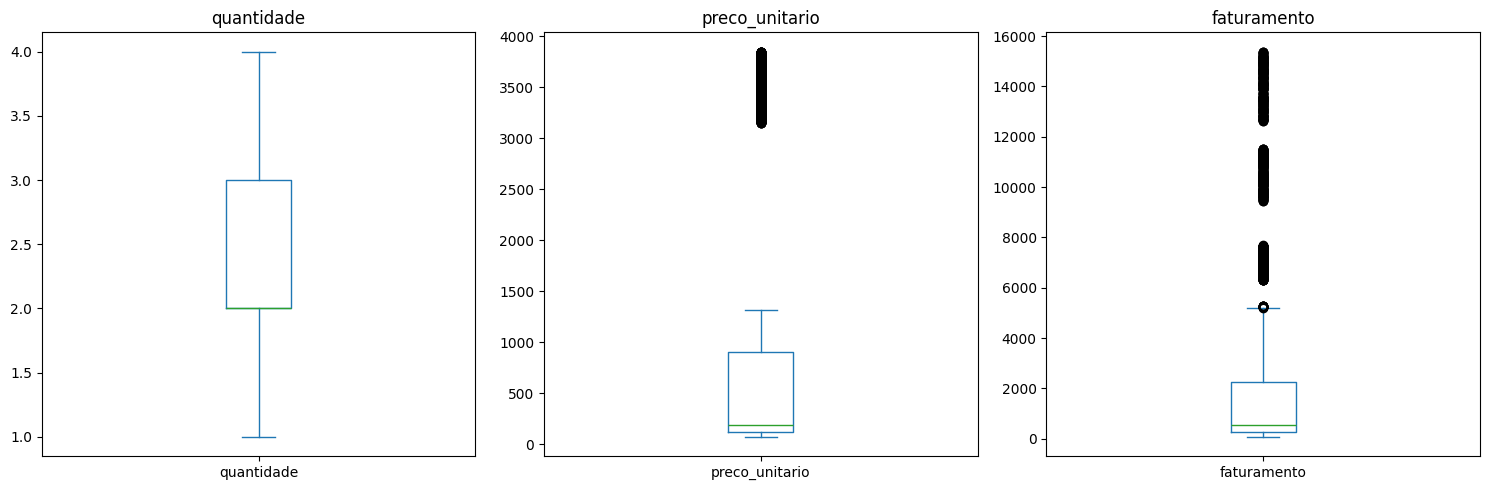

In [132]:
plt.figure(figsize=(15,5))
for i, col in enumerate(cols):
    plt.subplot(1,3,i+1)
    data = df[col]
    data = data[data>0]
    data.plot.box()
    plt.title(col)
plt.tight_layout()
plt.show()

In [133]:
#log scale

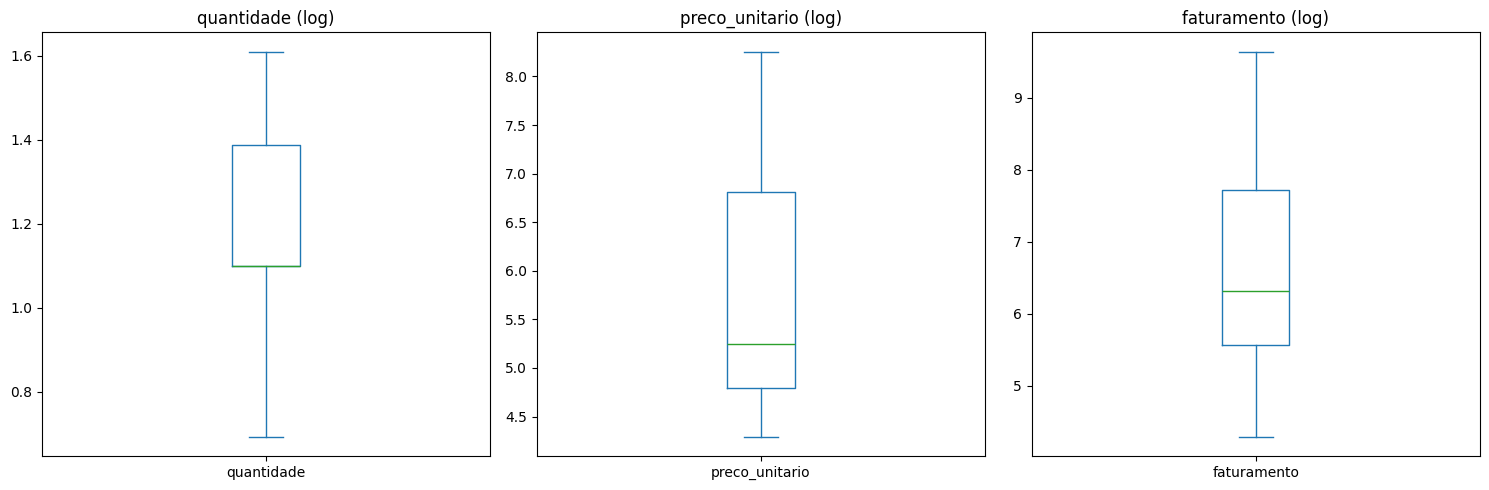

In [134]:
plt.figure(figsize=(15,5))

for i, col in enumerate(cols):
    plt.subplot(1,3,i+1)
    
    data = df[col]
    data = data[data > 0]
    
    data_log = np.log1p(data)  
    
    data_log.plot.box()
    plt.title(f'{col} (log)')

plt.tight_layout()
plt.show()

In [135]:
# Revenue x Quantity 

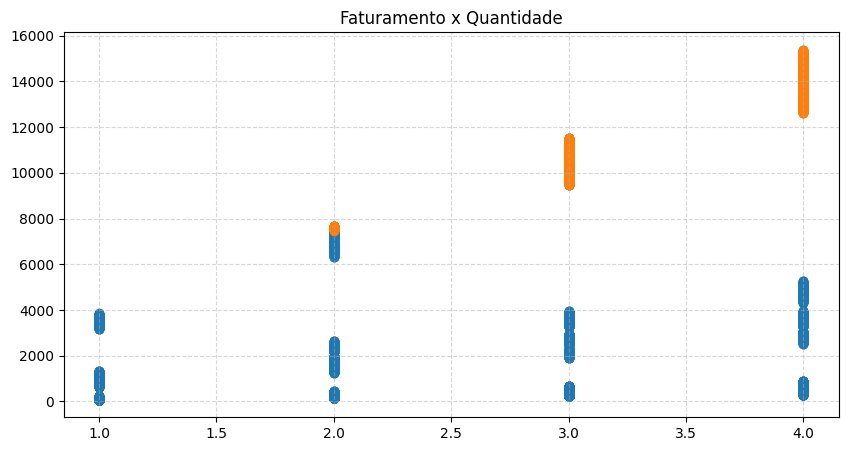

In [136]:
q95 = df["faturamento"].quantile(0.95)

plt.figure(figsize=(10,5))
plt.scatter(df["quantidade"], df["faturamento"], alpha=0.4)

outliers = df[df["faturamento"] > q95]
plt.scatter(outliers["quantidade"], outliers["faturamento"])

plt.title("Faturamento x Quantidade")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [137]:
# boxplot categorys 

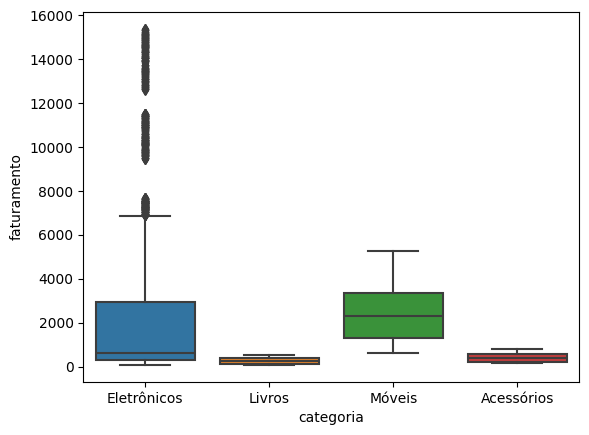

In [138]:
sns.boxplot(x='categoria',y='faturamento',data=df)
plt.show()

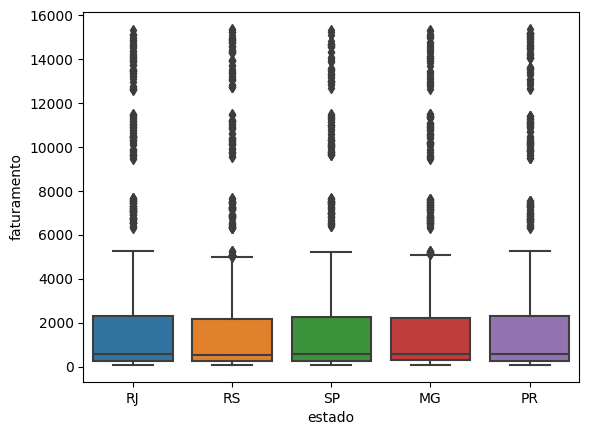

In [139]:
sns.boxplot(x='estado',y='faturamento',data=df)
plt.show()

In [140]:
# Descritivy analysis

In [141]:
# reveue per product

In [142]:
revenue_per_product = df.loc[:,["produto","faturamento"]].groupby("produto").sum().reset_index().sort_values(by='faturamento',ascending=False)

In [143]:
revenue_per_product

,produto,faturamento
8,Notebook,8290852.39
4,Mesa,3092939.21
6,Monitor,2364641.86
0,Cadeira,1629832.30
1,Fone,495633.09
5,Mochila,460376.91
9,Teclado,384771.59
2,Livro Python,296630.22
3,Livro SQL,247460.70
7,Mouse,205764.16


In [144]:
# revenue per category

In [145]:
revenue_per_category = df.loc[:,["categoria","faturamento"]].groupby("categoria").sum().reset_index().sort_values(by='faturamento',ascending=False)

In [146]:
revenue_per_category.reset_index()

,index,categoria,faturamento
0,1,Eletrônicos,11741663.09
1,3,Móveis,4722771.51
2,2,Livros,544090.92
3,0,Acessórios,460376.91


In [147]:
# revenue per client

In [148]:
revenue_per_client =  df.loc[:,["cliente","faturamento"]].groupby("cliente").sum().reset_index().sort_values(by='faturamento',ascending=False)

In [149]:
revenue_per_client

,cliente,faturamento
210,Mathias,122641.69
32,Asafe,121077.15
177,Lunna,111178.92
57,Carlos Eduardo,110931.92
263,Thiago,107474.24
...,...,...
186,Marcos Vinicius,24779.10
105,Guilherme,24450.71
30,Arthur Gabriel,24413.17
206,Mariane,22230.06


In [150]:
# grafic revenue per category

In [151]:
rpc  = revenue_per_category.reset_index()

In [152]:
rpc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        4 non-null      int64  
 1   categoria    4 non-null      object 
 2   faturamento  4 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 228.0+ bytes


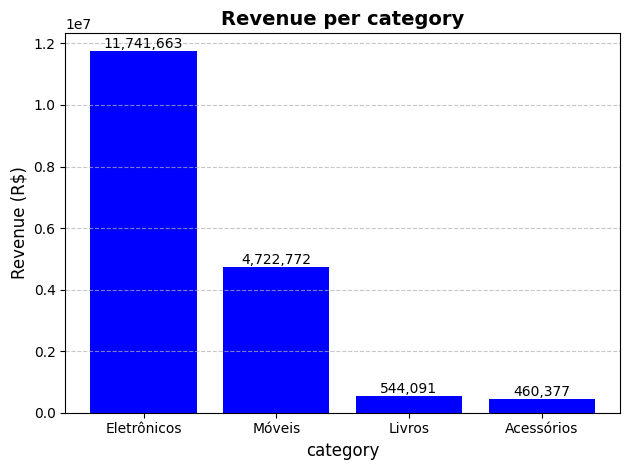

In [153]:
bars = plt.bar(rpc['categoria'],rpc['faturamento'],color='blue')

plt.xlabel('category',fontsize=12)
plt.ylabel('Revenue (R$)',fontsize=12)
plt.title('Revenue per category', fontsize=14,fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()